# 1. Data Exploration & Preparation
## MVTec Metal Nut - Binary Classification (Good/Bad)

Setup environment, explore dataset structure, and prepare dataloaders with augmentation

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
import numpy as np
from pathlib import Path
from PIL import Image
import pickle

# For reproducibility
torch.manual_seed(43)
np.random.seed(43)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## Explore Dataset Structure

In [2]:
# Dataset path
dataset_root = Path("../data/metal_nut")
defect_types = ['bent', 'color', 'flip', 'scratch']

# Explore dataset structure
print("=== MVTec Metal Nut Dataset Structure ===")
for split in ['train', 'test']:
    split_path = dataset_root / split
    print(f"\n{split.upper()} set:")
    if split_path.exists():
        for category in sorted(split_path.iterdir()):
            if category.is_dir():
                image_count = len(list(category.glob('*.png'))) + len(list(category.glob('*.jpg')))
                print(f"  {category.name:10s}: {image_count:3d} images")
    else:
        print(f"    Path not found: {split_path}")

=== MVTec Metal Nut Dataset Structure ===

TRAIN set:
  good      : 220 images

TEST set:
  bent      :  25 images
  color     :  22 images
  flip      :  23 images
  good      :  22 images
  scratch   :  23 images


## Custom Dataset Class

In [3]:
class MVTecBinaryDataset(Dataset):
    """
    Binary classification dataset for MVTec Metal Nut
    0 = Good
    1 = Defective (bent, color, flip, scratch)
    """
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = Path(root_dir)
        self.split = split
        self.transform = transform
        self.images = []
        self.labels = []
        self.defect_types = ['bent', 'color', 'flip', 'scratch']
        
        self._load_dataset()
    
    def _load_dataset(self):
        split_dir = self.root_dir / self.split
        
        # Load good images (label 0)
        good_dir = split_dir / 'good'
        if good_dir.exists():
            for img_path in sorted(good_dir.glob('*.png')):
                self.images.append(str(img_path))
                self.labels.append(0)
        
        # Load defective images (label 1)
        for defect_type in self.defect_types:
            defect_dir = split_dir / defect_type
            if defect_dir.exists():
                for img_path in sorted(defect_dir.glob('*.png')):
                    self.images.append(str(img_path))
                    self.labels.append(1)
        
        print(f"Loaded {len(self.images)} images from {self.split} split")
        print(f"  Good: {sum(1 for l in self.labels if l == 0)}")
        print(f"  Defective: {sum(1 for l in self.labels if l == 1)}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image, label


# Test dataset loading
print("\n=== Loading Datasets ===")
train_dataset_raw = MVTecBinaryDataset(dataset_root, split='train')
test_dataset_raw = MVTecBinaryDataset(dataset_root, split='test')


=== Loading Datasets ===
Loaded 220 images from train split
  Good: 220
  Defective: 0
Loaded 115 images from test split
  Good: 22
  Defective: 93


## Data Augmentation & DataLoaders

In [4]:
# ImageNet normalization (important for pretrained models)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# Training transforms - basic augmentation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Validation/Test transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Create datasets with transforms
train_dataset = MVTecBinaryDataset(dataset_root, split='train', transform=train_transform)
test_dataset = MVTecBinaryDataset(dataset_root, split='test', transform=val_transform)

# Split train into train/validation (80/20)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
indices = torch.randperm(len(train_dataset)).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(train_dataset, val_indices)

# DataLoaders with proper Windows compatibility
batch_size = 32
num_workers = 0  # Default to 0 for safety

pin_memory = True if torch.cuda.is_available() else False

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, 
                          num_workers=num_workers, pin_memory=pin_memory)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, 
                        num_workers=num_workers, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, 
                         num_workers=num_workers, pin_memory=pin_memory)

print(f"\n=== DataLoader Sizes ===")
print(f"  Train:      {len(train_subset)} images")
print(f"  Validation: {len(val_subset)} images")
print(f"  Test:       {len(test_dataset)} images")
print(f"  Batch size: {batch_size}")
print(f"  Num workers: {num_workers}")

Loaded 220 images from train split
  Good: 220
  Defective: 0
Loaded 115 images from test split
  Good: 22
  Defective: 93

=== DataLoader Sizes ===
  Train:      176 images
  Validation: 44 images
  Test:       115 images
  Batch size: 32
  Num workers: 0


## Save Datasets for Next Notebooks

Save the raw datasets and indices so dataloaders can be recreated in each notebook.

## Dataset Visualization & Statistics

Visualize sample images and check class distribution and image statistics

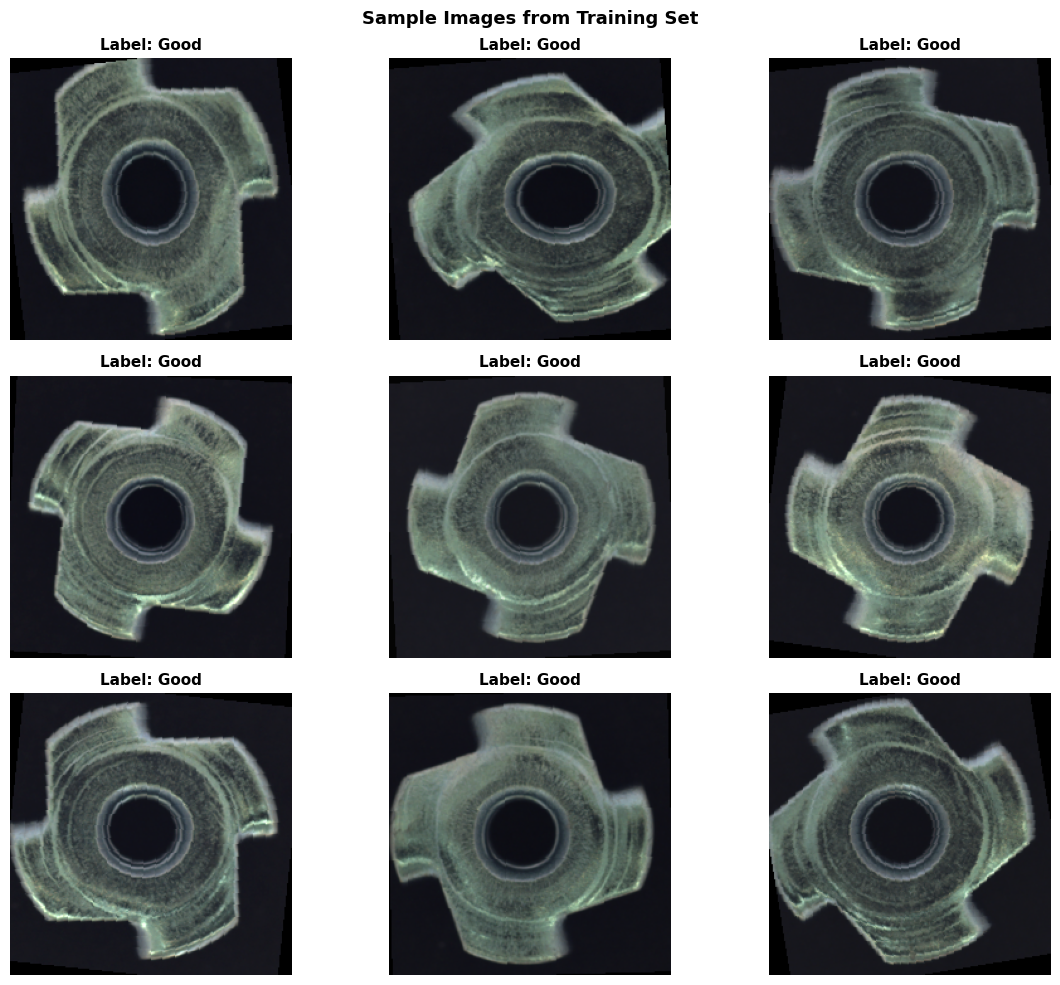

 Sample visualization complete


In [5]:
import matplotlib.pyplot as plt

# Function to denormalize images for visualization
def denormalize(img, mean, std):
    img = img.clone()
    for i in range(3):
        img[i] = img[i] * std[i] + mean[i]
    return img.clamp(0, 1)

# Get first batch from train loader
first_batch = next(iter(train_loader))
images, labels = first_batch

# Visualize 9 random samples
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

class_names = {0: 'Good', 1: 'Defective'}
for idx in range(min(9, len(images))):
    ax = axes[idx]
    
    # Denormalize and show image
    img = denormalize(images[idx], imagenet_mean, imagenet_std)
    img = img.permute(1, 2, 0).numpy()
    ax.imshow(img)
    
    label_name = class_names[labels[idx].item()]
    ax.set_title(f"Label: {label_name}", fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Images from Training Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(" Sample visualization complete")

## Class Distribution & Statistics

CLASS DISTRIBUTION

TRAIN SET (176 total):
  Good:      176 (100.0%)
  Defective:   0 (  0.0%)

VALIDATION SET (44 total):
  Good:       44 (100.0%)
  Defective:   0 (  0.0%)

TEST SET (115 total):
  Good:       22 ( 19.1%)
  Defective:  93 ( 80.9%)


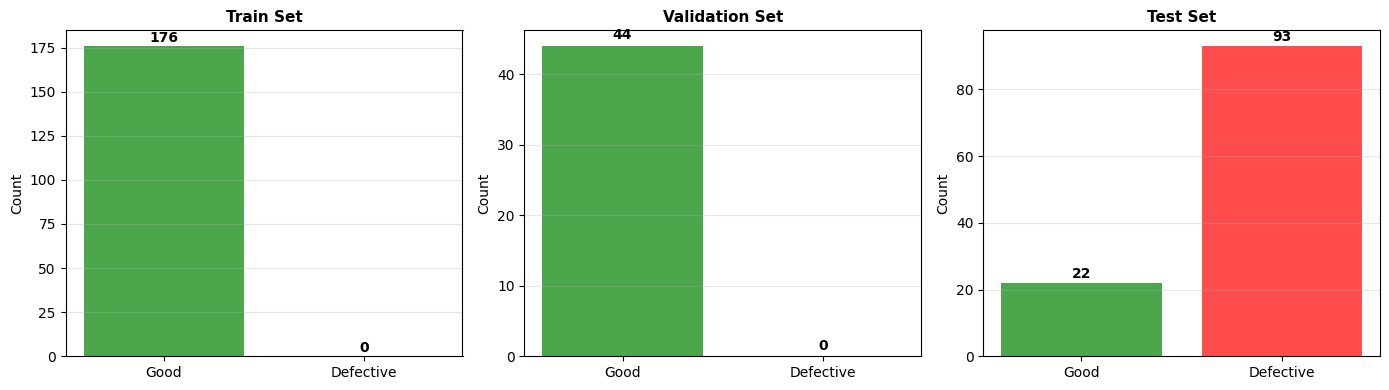


Class distribution analysis complete


In [6]:
# Calculate class distribution
train_labels = [train_dataset_raw.labels[i] for i in train_indices]
val_labels = [train_dataset_raw.labels[i] for i in val_indices]
test_labels = test_dataset_raw.labels

def count_classes(labels):
    good = sum(1 for l in labels if l == 0)
    defective = sum(1 for l in labels if l == 1)
    return good, defective

train_good, train_defective = count_classes(train_labels)
val_good, val_defective = count_classes(val_labels)
test_good, test_defective = count_classes(test_labels)

print("="*60)
print("CLASS DISTRIBUTION")
print("="*60)
print(f"\nTRAIN SET ({len(train_labels)} total):")
print(f"  Good:      {train_good:3d} ({100*train_good/len(train_labels):5.1f}%)")
print(f"  Defective: {train_defective:3d} ({100*train_defective/len(train_labels):5.1f}%)")

print(f"\nVALIDATION SET ({len(val_labels)} total):")
print(f"  Good:      {val_good:3d} ({100*val_good/len(val_labels):5.1f}%)")
print(f"  Defective: {val_defective:3d} ({100*val_defective/len(val_labels):5.1f}%)")

print(f"\nTEST SET ({len(test_labels)} total):")
print(f"  Good:      {test_good:3d} ({100*test_good/len(test_labels):5.1f}%)")
print(f"  Defective: {test_defective:3d} ({100*test_defective/len(test_labels):5.1f}%)")

# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, (data, labels, title) in enumerate([
    ('Train', train_labels, 'Train Set'),
    ('Val', val_labels, 'Validation Set'),
    ('Test', test_labels, 'Test Set')
]):
    good, defective = count_classes(labels)
    axes[idx].bar(['Good', 'Defective'], [good, defective], color=['green', 'red'], alpha=0.7)
    axes[idx].set_title(title, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add count labels on bars
    for i, (label, count) in enumerate([('Good', good), ('Defective', defective)]):
        axes[idx].text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nClass distribution analysis complete")

In [7]:
import os
import json

# Create data directory
os.makedirs('../data/processed', exist_ok=True)

# Save raw datasets (not loaders)
datasets = {
    'train_dataset': train_dataset,
    'test_dataset': test_dataset,
    'train_indices': train_indices,
    'val_indices': val_indices
}

pickle.dump(datasets, open('../data/processed/datasets.pkl', 'wb'))
print("  Datasets saved to: ../data/processed/datasets.pkl")

# Save normalization and config
config = {
    'imagenet_mean': imagenet_mean,
    'imagenet_std': imagenet_std,
    'batch_size': batch_size,
    'input_size': 224,
}

pickle.dump(config, open('../data/processed/config.pkl', 'wb'))
print("  Config saved to: ../data/processed/config.pkl")

# Save dataset statistics as JSON
dataset_stats = {
    'train_size': len(train_subset),
    'val_size': len(val_subset),
    'test_size': len(test_dataset),
    'num_classes': 2,
    'class_labels': {0: 'Good', 1: 'Defective'},
    'normalization': {
        'mean': imagenet_mean,
        'std': imagenet_std
    },
    'class_distribution': {
        'train': {'good': train_good, 'defective': train_defective},
        'val': {'good': val_good, 'defective': val_defective},
        'test': {'good': test_good, 'defective': test_defective}
    }
}

with open('../data/processed/dataset_stats.json', 'w') as f:
    json.dump(dataset_stats, f, indent=2)
print("  Dataset stats saved to: ../data/processed/dataset_stats.json")

print("\n" + "="*60)
print("  DATA PREPARATION COMPLETE")
print("="*60)

  Datasets saved to: ../data/processed/datasets.pkl
  Config saved to: ../data/processed/config.pkl
  Dataset stats saved to: ../data/processed/dataset_stats.json

  DATA PREPARATION COMPLETE
